In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [2]:
import os
import pandas as pd
import numpy as np
import data.constants
from data import plotting
import models.constants
from models import processing

import importlib
importlib.reload(data.constants)
importlib.reload(models.constants)
importlib.reload(plotting)
importlib.reload(processing)

<module 'models.processing' from '/Users/paulb/Desktop/code/research/babi/models/processing.py'>

In [3]:
training_set = processing.get_training_dataset()
training_set.shape

(693, 64)

Convolutional Autoencoder

In [4]:
import matplotlib.pyplot as plt
from models import autoencoders
from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D

training_set = processing.get_training_dataset()
print(training_set.shape)

# h, w, _ = input_shape
# ds_steps = 2  # Use 2 downsampling steps to ensure output shape matches input
# h_ds, w_ds = h // (2 ** ds_steps), w // (2 ** ds_steps)
# flattened_dim = h_ds * w_ds * 64
# latent_dim = 128

# cae = Sequential(name='ConvolutionalAutoencoder', layers=[
#     Input(shape=(16, 2, 1)), 
#     Conv2D(16, (3, 3), activation='relu', padding='same'), 
#     MaxPooling2D((2, 2)), # (8, 1, 16)
#     Conv2D(8, (3, 3), activation='relu', padding='same'), # (8, 1, 8)

#     MaxPooling2D((2, 2)), # latent space layer (4, 1, 8)

#     Conv2DTranspose(8, (3, 3), activation='relu', padding='same'), # 
#     UpSampling2D((2, 2)),
#     Conv2DTranspose(8, (3, 3), activation='relu', padding='same'),
#     UpSampling2D((2, 2)),
#     Conv2DTranspose(16, (3, 3), activation='relu', padding='same'),
#     UpSampling2D((2,2)),
#     Conv2D(3, (3, 3), padding='same'),
# ])

input_dim = output_dim = training_set.shape[1]
hidden_dim = int(input_dim * 0.8)
latent_dim = input_dim // 2

print(f"In/Out dim: {input_dim}")
print(f"Hidden dim: {hidden_dim}")
print(f"Latent dim: {latent_dim}")

dae =  Sequential([
    Input(shape=(input_dim,)),
    Dense(hidden_dim, activation='relu'),
    Dense(latent_dim, activation='relu'), # latent space (bottleneck)
    Dense(hidden_dim, activation='relu'),
    Dense(output_dim, activation='sigmoid'),
])


dae.compile(optimizer='adam', loss='mse')
ca_history: dict = dae.fit(training_set, training_set, epochs=32, batch_size=32)

(693, 64)
In/Out dim: 64
Hidden dim: 51
Latent dim: 32
Epoch 1/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - loss: 0.1165 
Epoch 2/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - loss: 0.0445
Epoch 3/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 0.0188
Epoch 4/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - loss: 0.0162
Epoch 5/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 0.0155
Epoch 6/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0149
Epoch 7/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 0.0142
Epoch 8/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 0.0134
Epoch 9/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - loss: 0.0126
Epoch 10/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 0.0121
Epoch 11/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - loss: 0.0116
Epoch 12/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - loss: 0.0111
Epoch 13/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0107
Epoch 14/32
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0103 
Epoch 

In [5]:
first_preprocessed_capnostream_file = os.listdir(os.path.join(data.constants.preprocessed_data_dir, "capnostream"))[1]
capnostream_file_df: pd.DataFrame = pd.read_pickle(os.path.join(data.constants.preprocessed_data_dir, "capnostream", first_preprocessed_capnostream_file))
print(capnostream_file_df.attrs)
signal = capnostream_file_df["co2_wave"].to_numpy()
time = np.arange(len(signal)) / data.constants.capnostream_sampling_rate
print(f"{len(signal)} samples  ({len(signal) / data.constants.capnostream_sampling_rate:.2f} seconds)")

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}
40405 samples  (2020.25 seconds)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


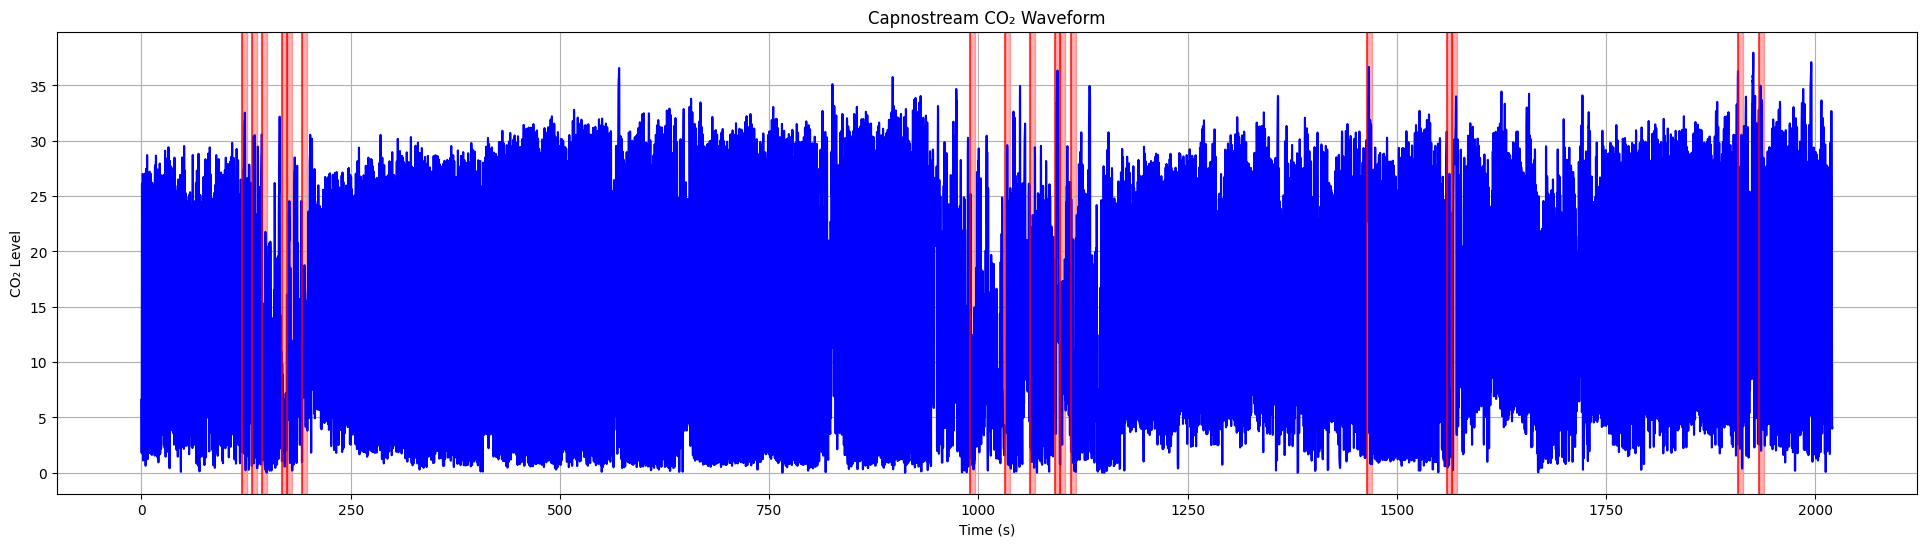

Anomaly at window 20, samples 120 to 126, viewing samples (np.int64(108), np.int64(138))


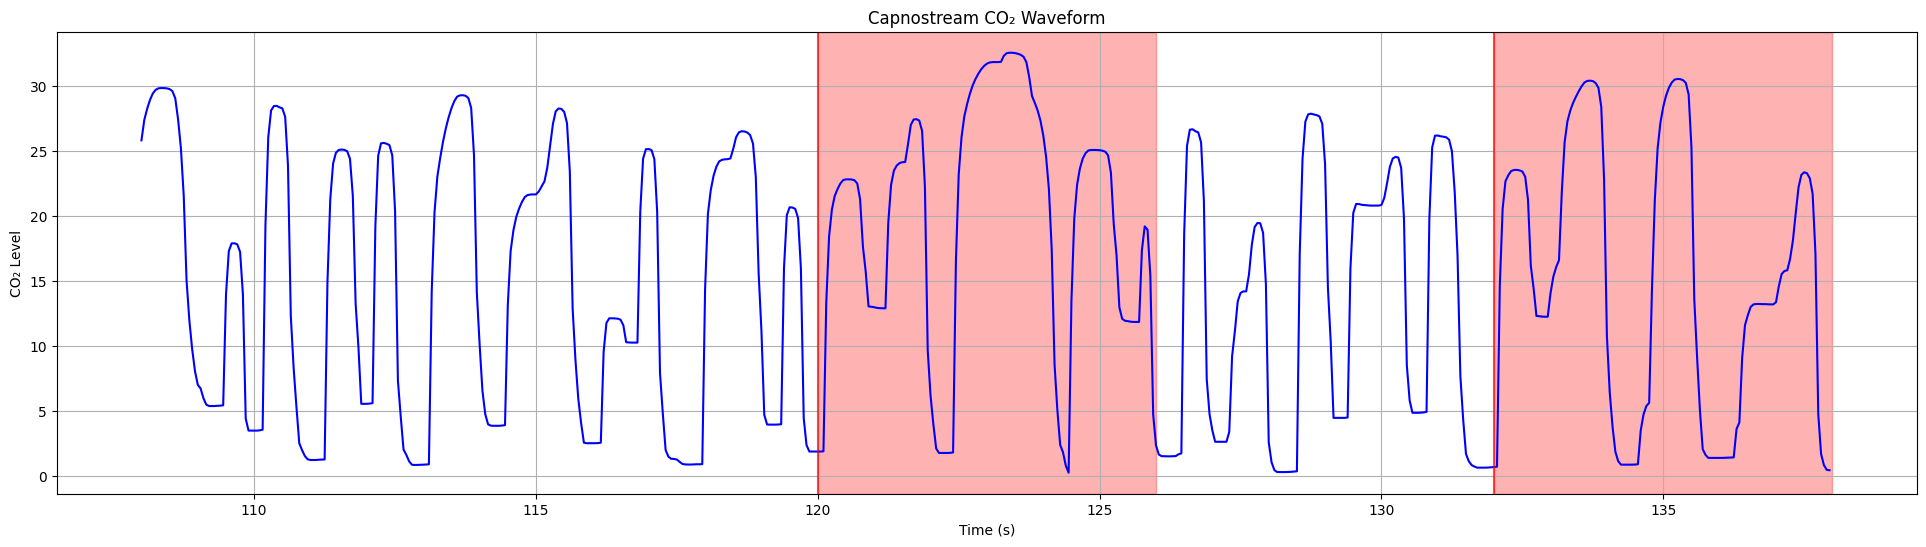

Anomaly at window 22, samples 132 to 138, viewing samples (np.int64(120), np.int64(150))


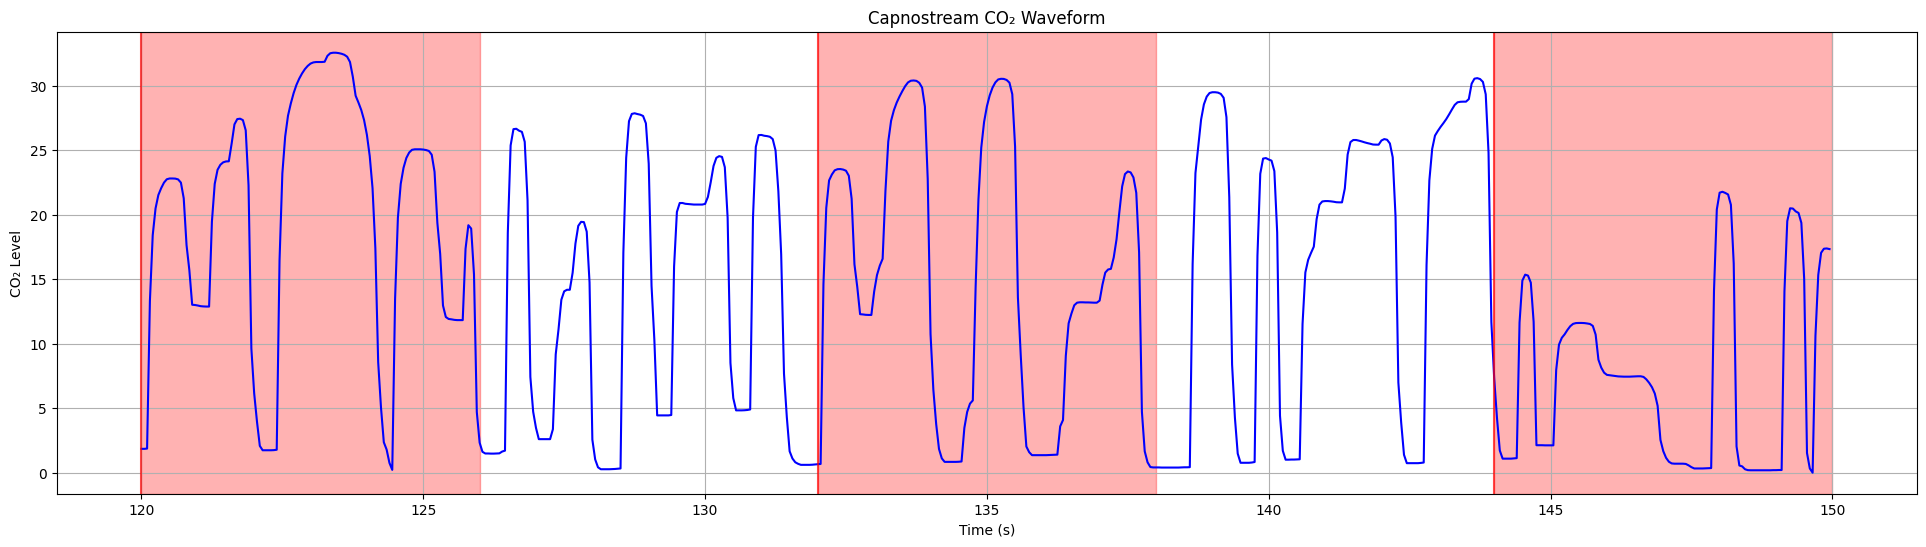

Anomaly at window 24, samples 144 to 150, viewing samples (np.int64(132), np.int64(162))


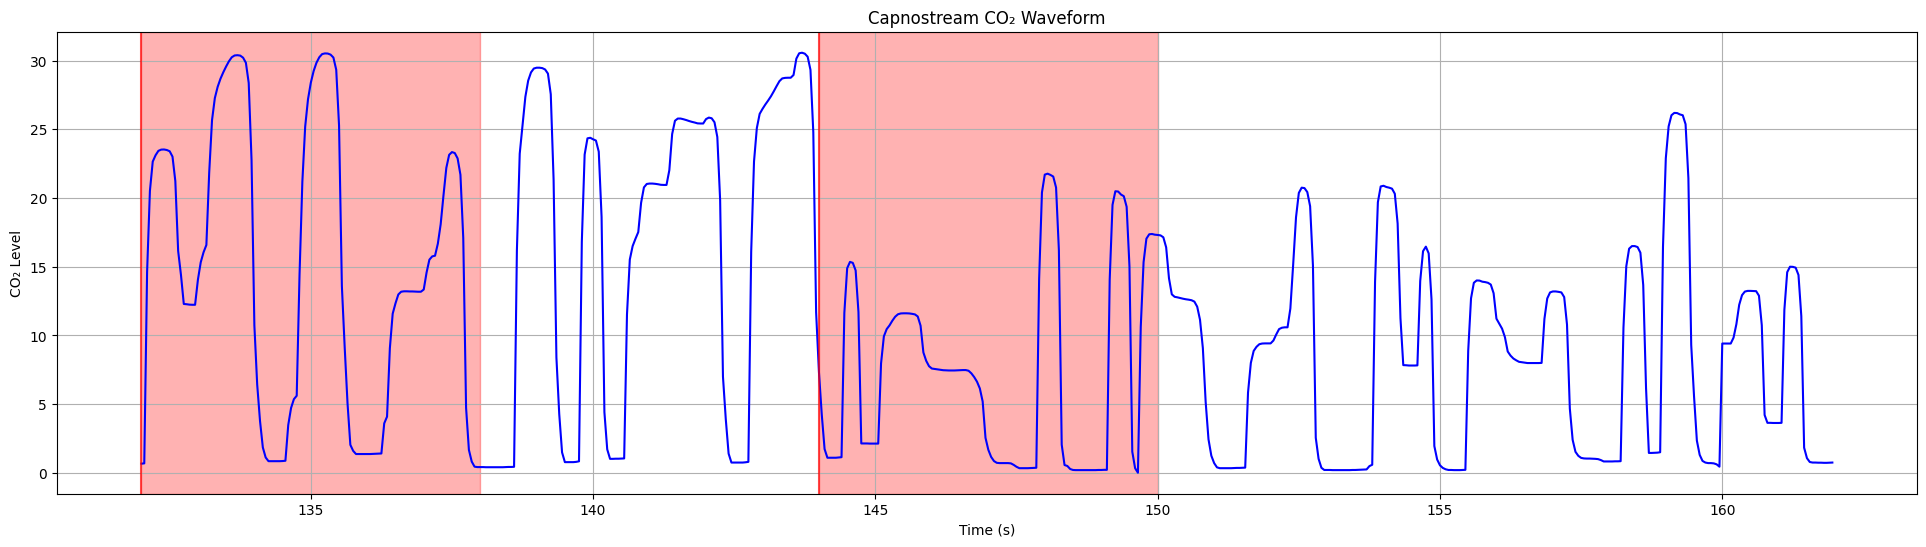

Anomaly at window 28, samples 168 to 174, viewing samples (np.int64(156), np.int64(186))


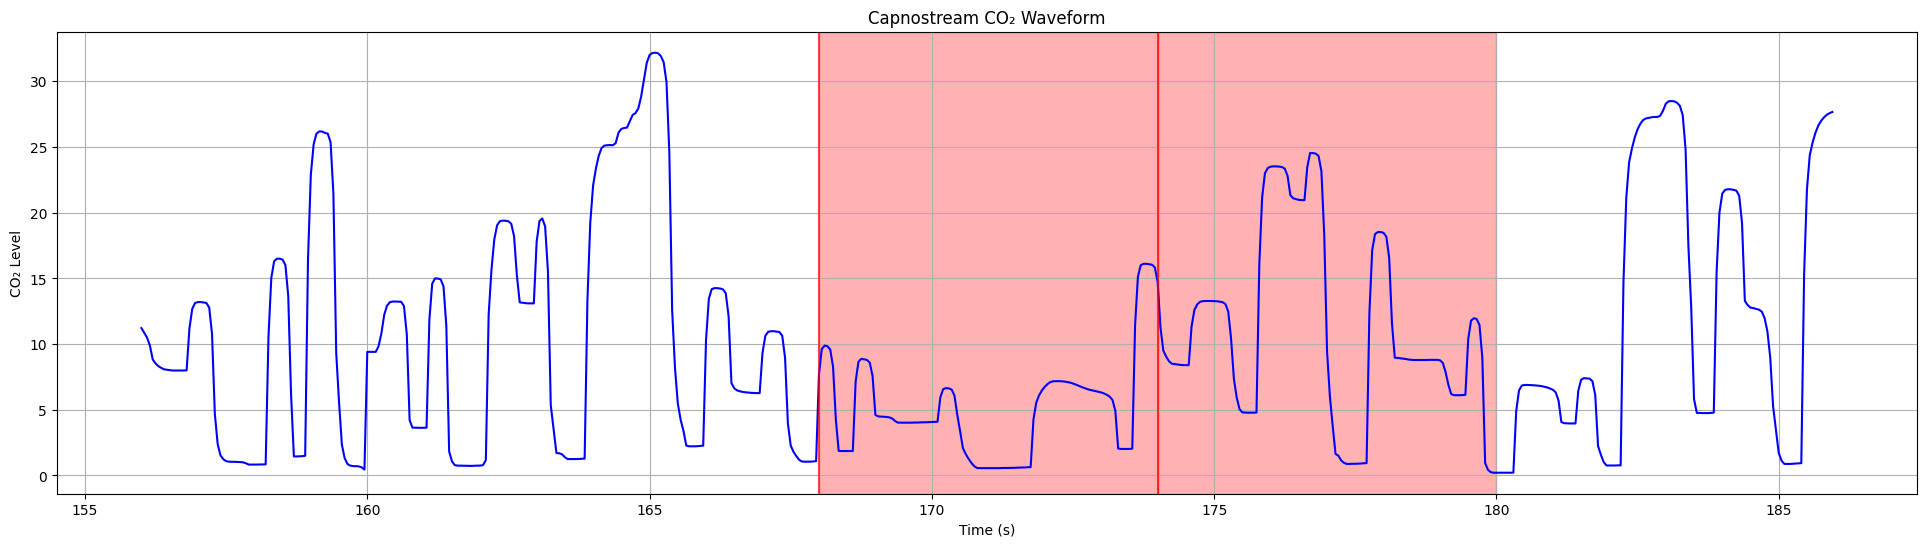

Anomaly at window 29, samples 174 to 180, viewing samples (np.int64(162), np.int64(192))


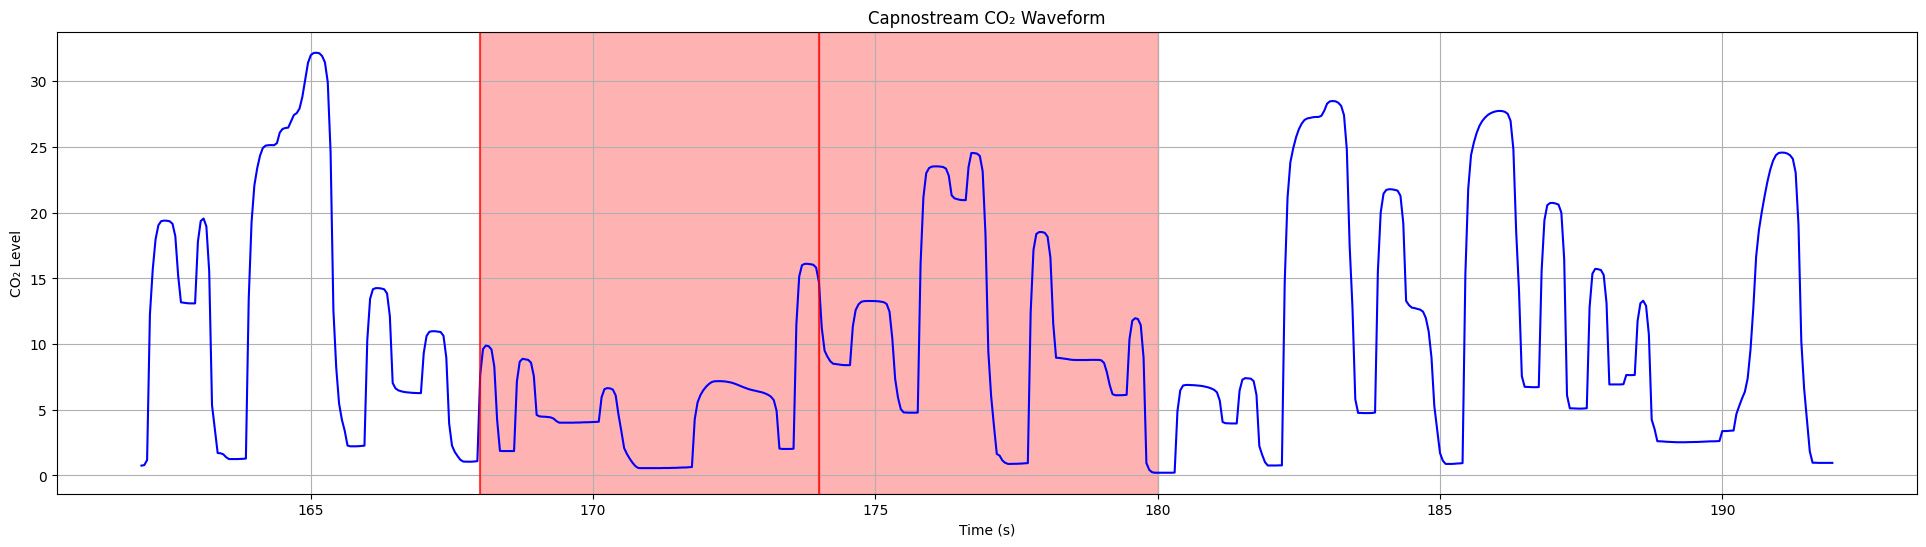

Anomaly at window 32, samples 192 to 198, viewing samples (np.int64(180), np.int64(210))


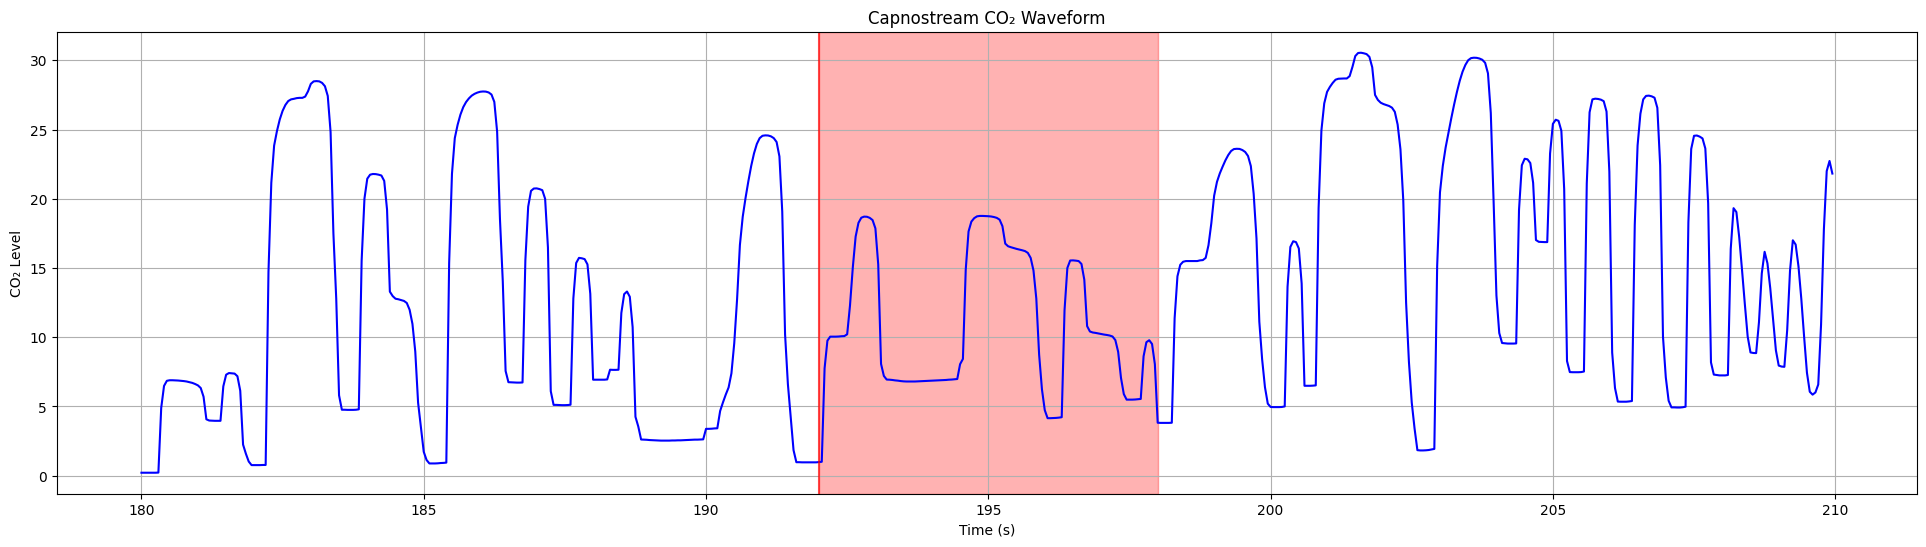

Anomaly at window 165, samples 990 to 996, viewing samples (np.int64(978), np.int64(1008))


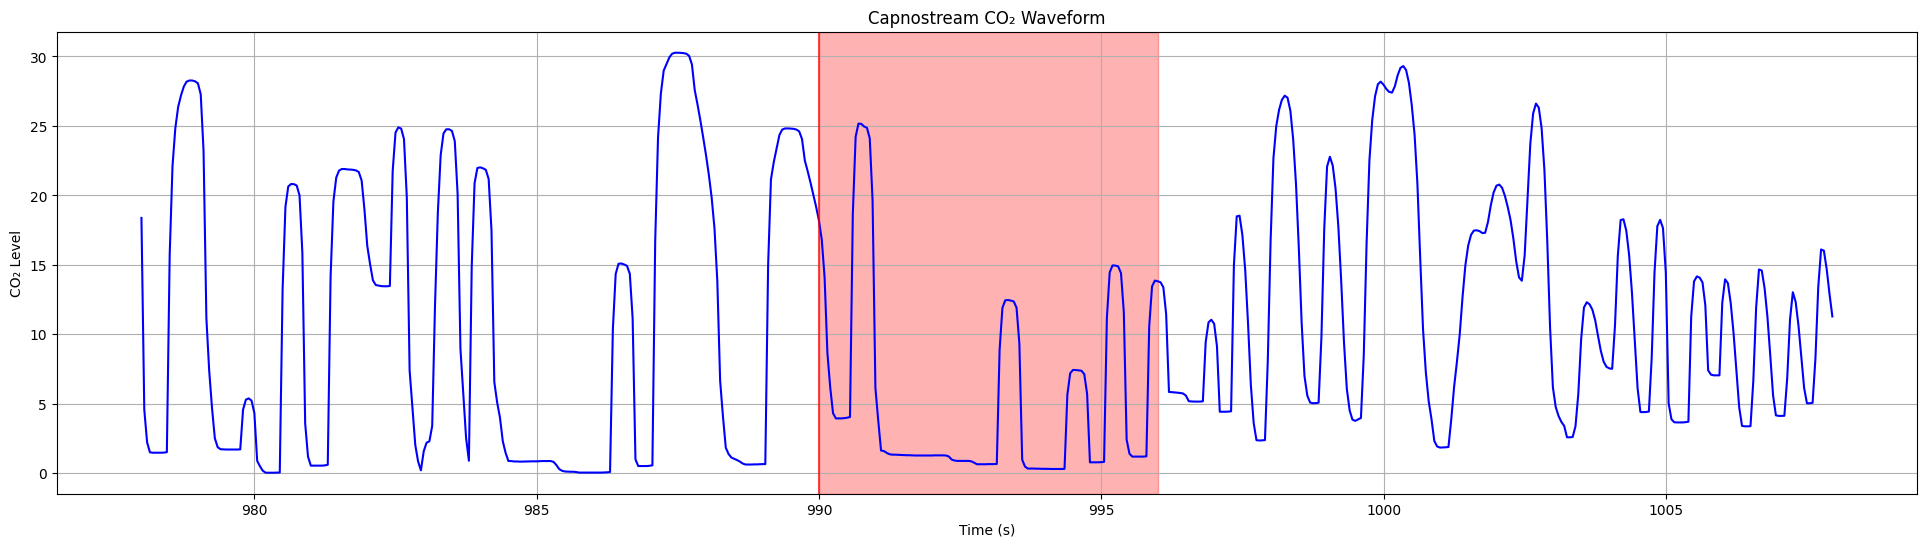

Anomaly at window 172, samples 1032 to 1038, viewing samples (np.int64(1020), np.int64(1050))


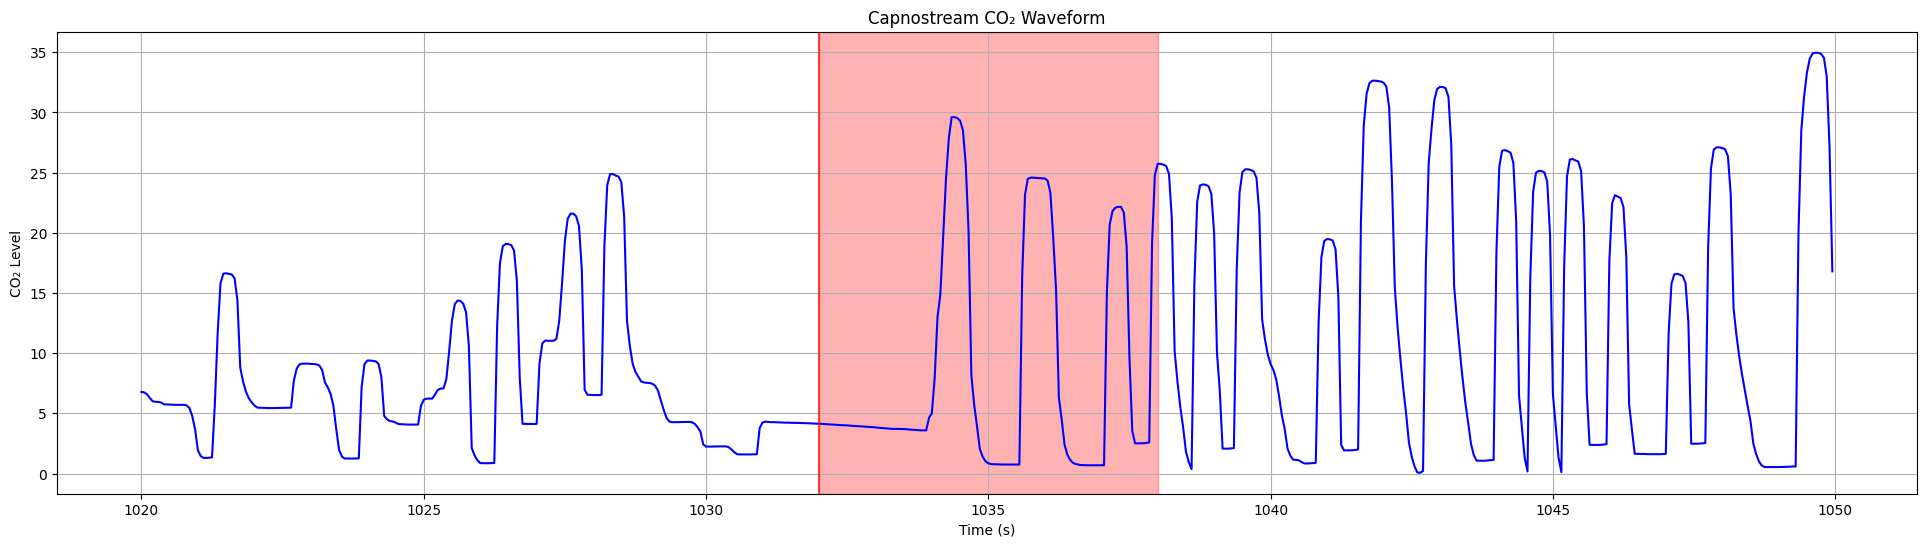

Anomaly at window 177, samples 1062 to 1068, viewing samples (np.int64(1050), np.int64(1080))


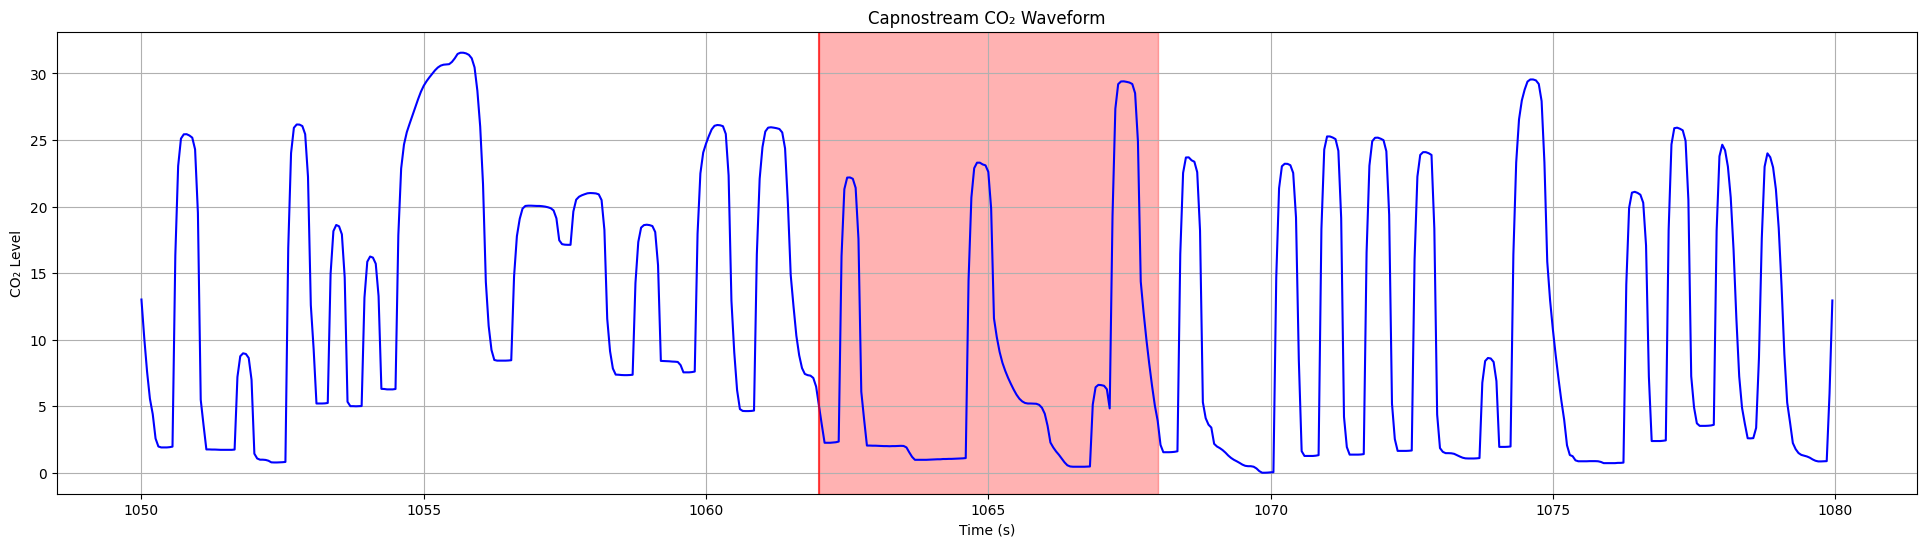

Anomaly at window 182, samples 1092 to 1098, viewing samples (np.int64(1080), np.int64(1110))


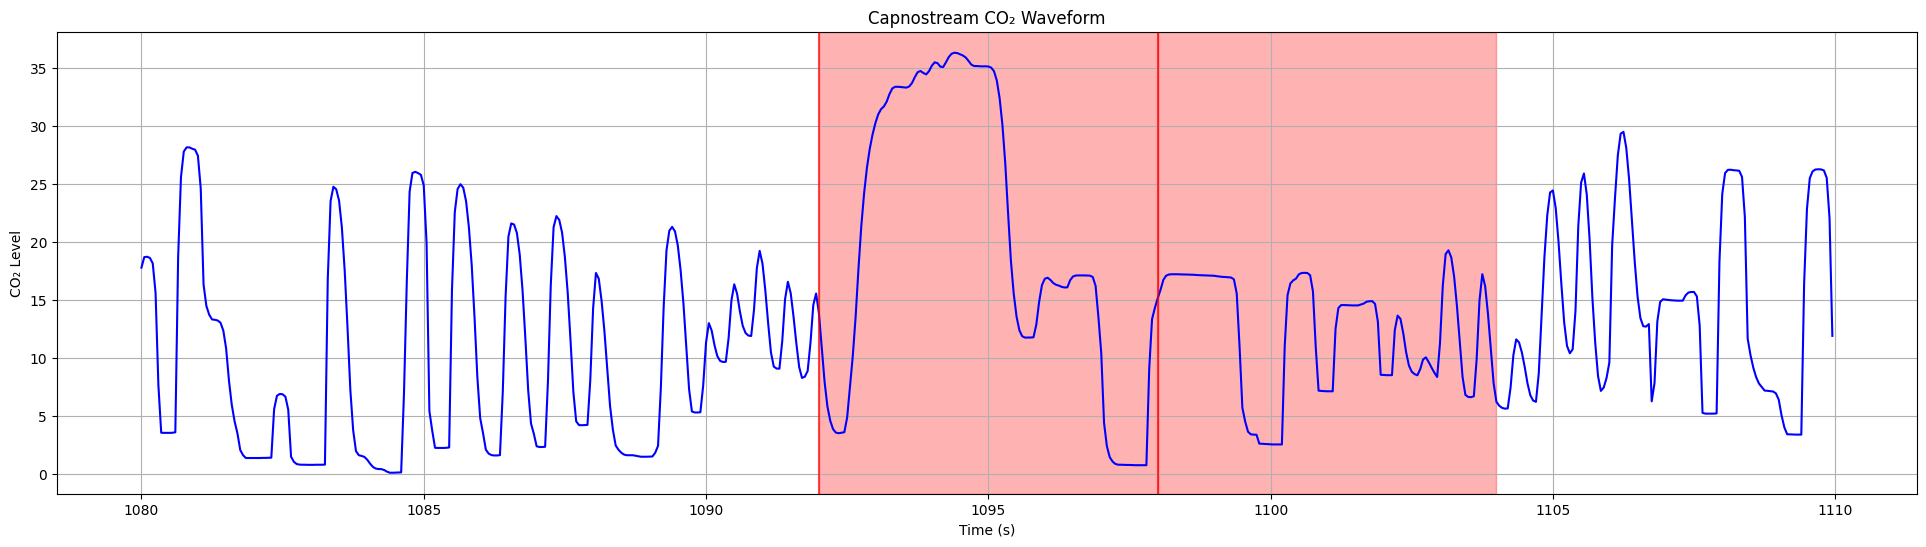

Anomaly at window 183, samples 1098 to 1104, viewing samples (np.int64(1086), np.int64(1116))


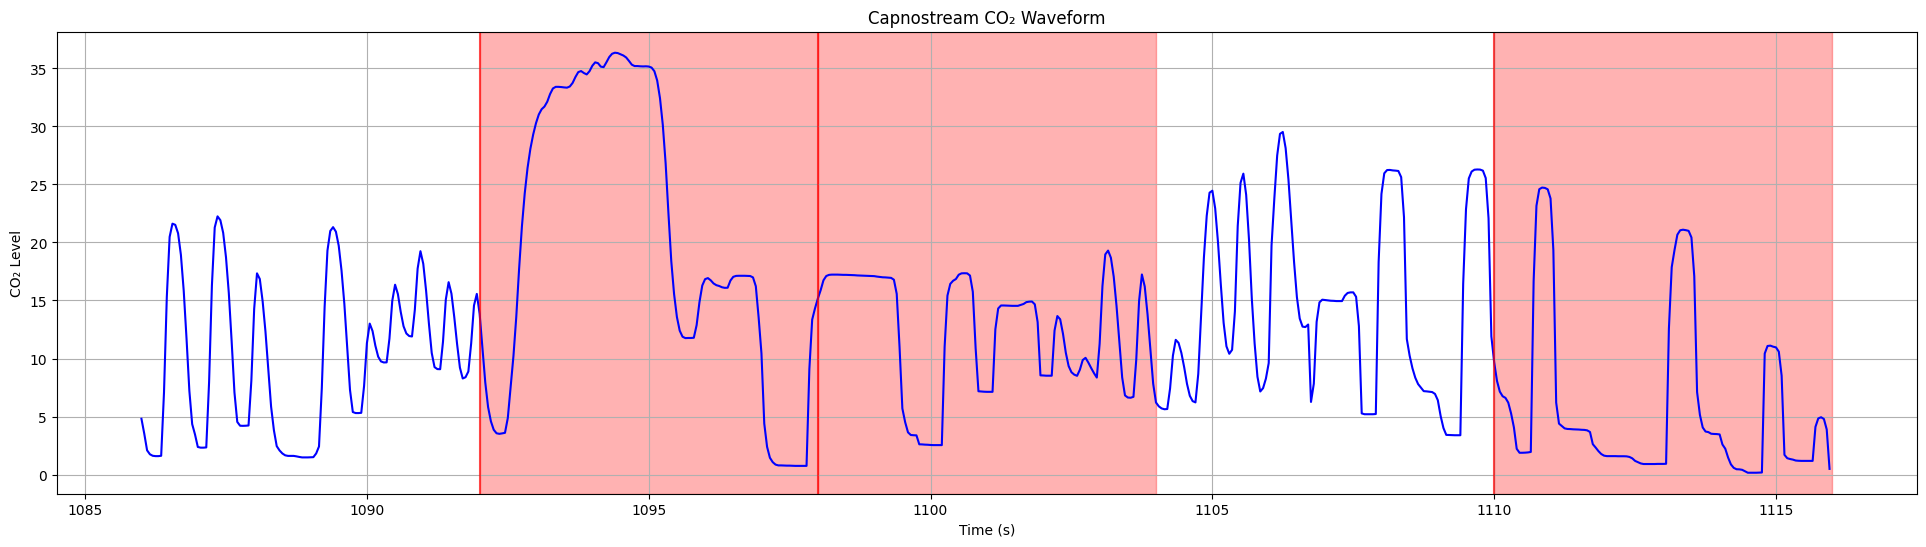

Anomaly at window 185, samples 1110 to 1116, viewing samples (np.int64(1098), np.int64(1128))


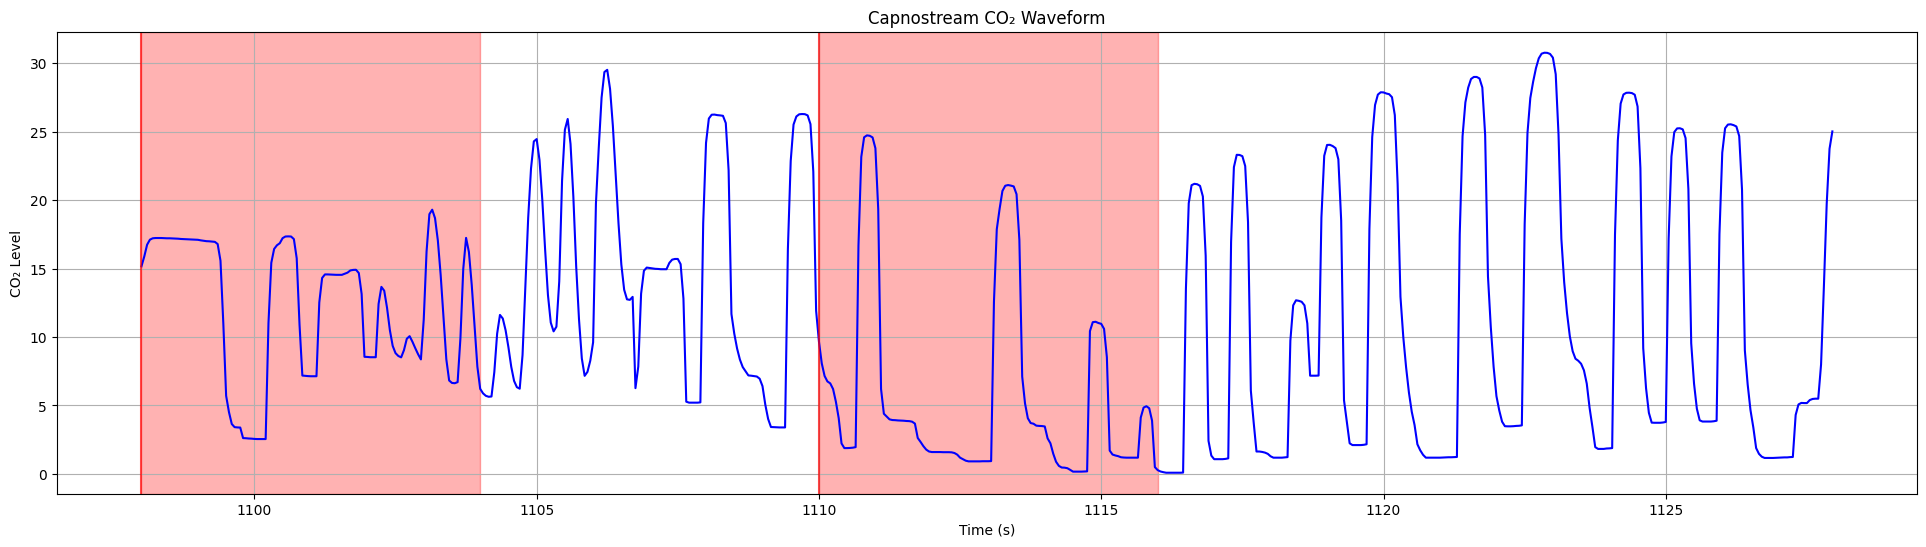

Anomaly at window 244, samples 1464 to 1470, viewing samples (np.int64(1452), np.int64(1482))


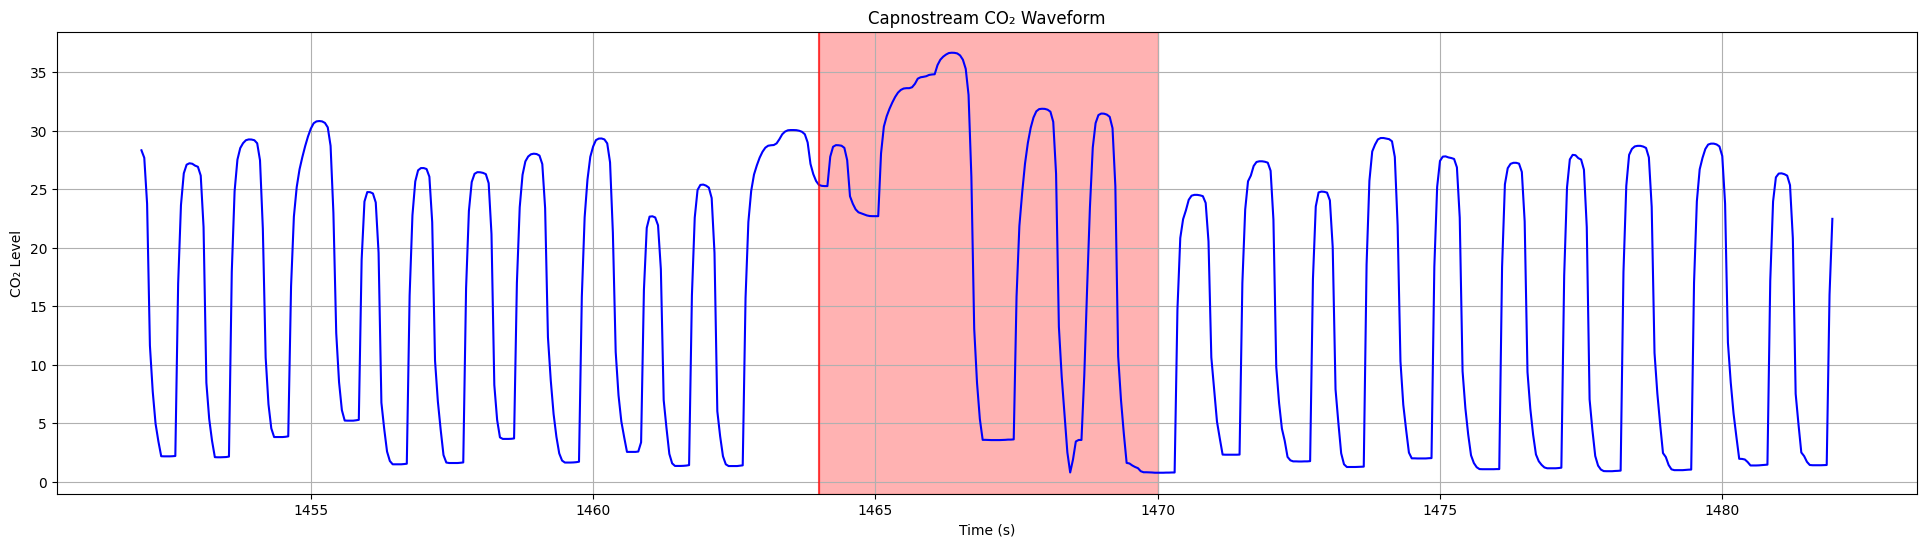

Anomaly at window 260, samples 1560 to 1566, viewing samples (np.int64(1548), np.int64(1578))


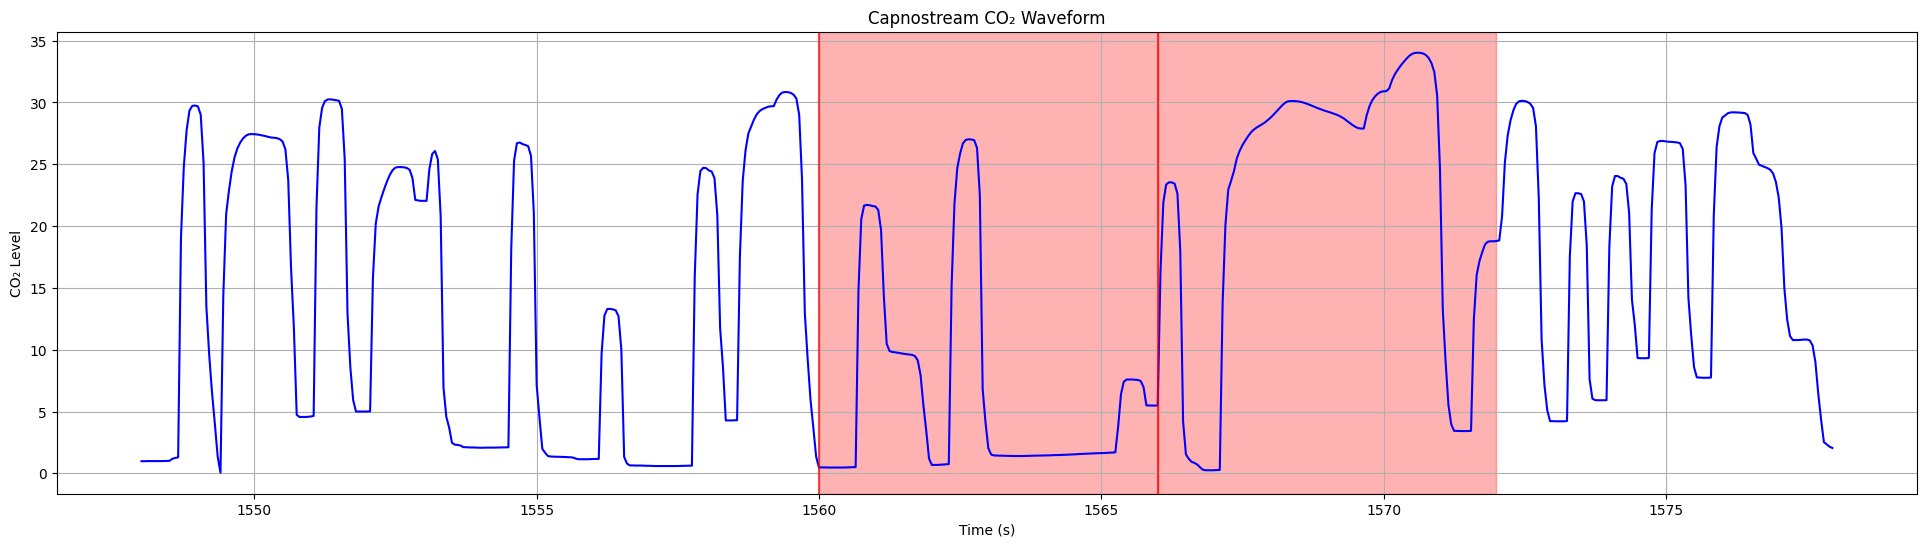

Anomaly at window 261, samples 1566 to 1572, viewing samples (np.int64(1554), np.int64(1584))


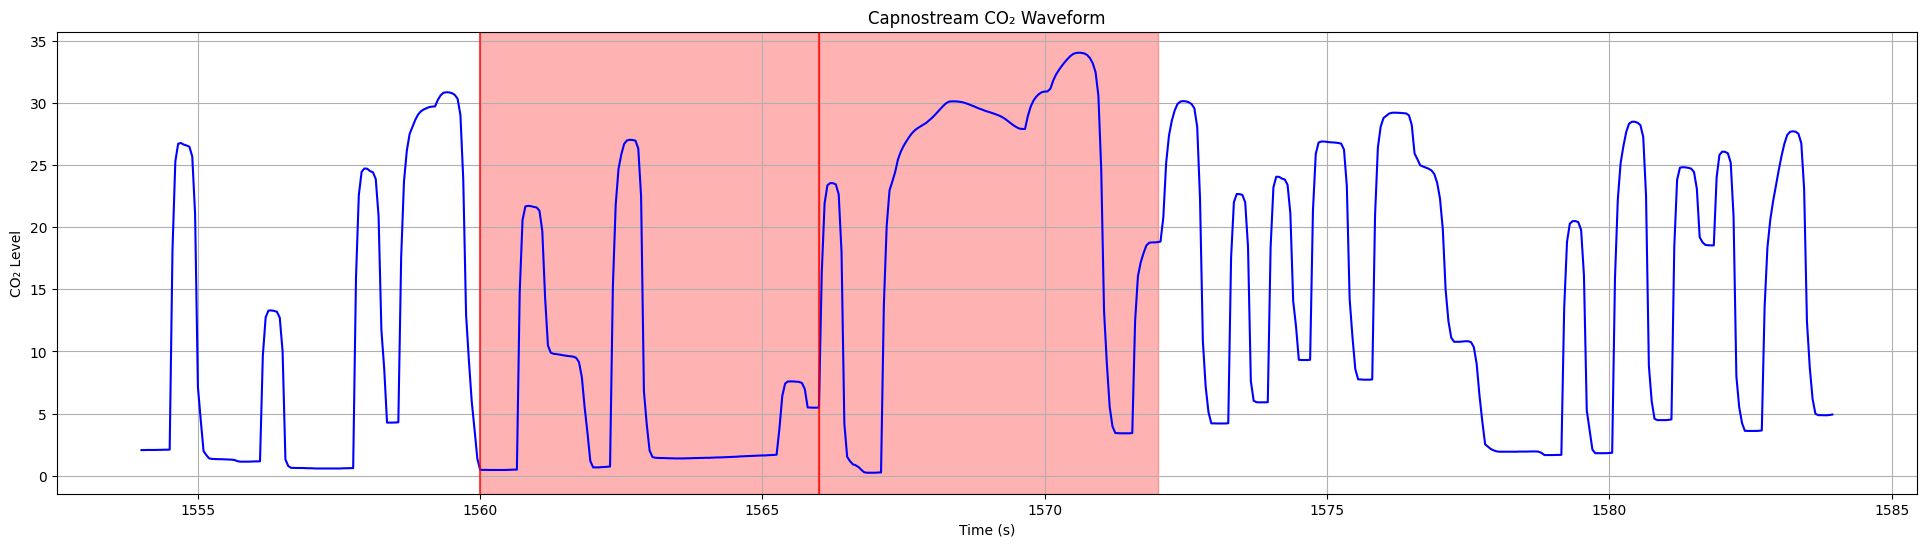

Anomaly at window 318, samples 1908 to 1914, viewing samples (np.int64(1896), np.int64(1926))


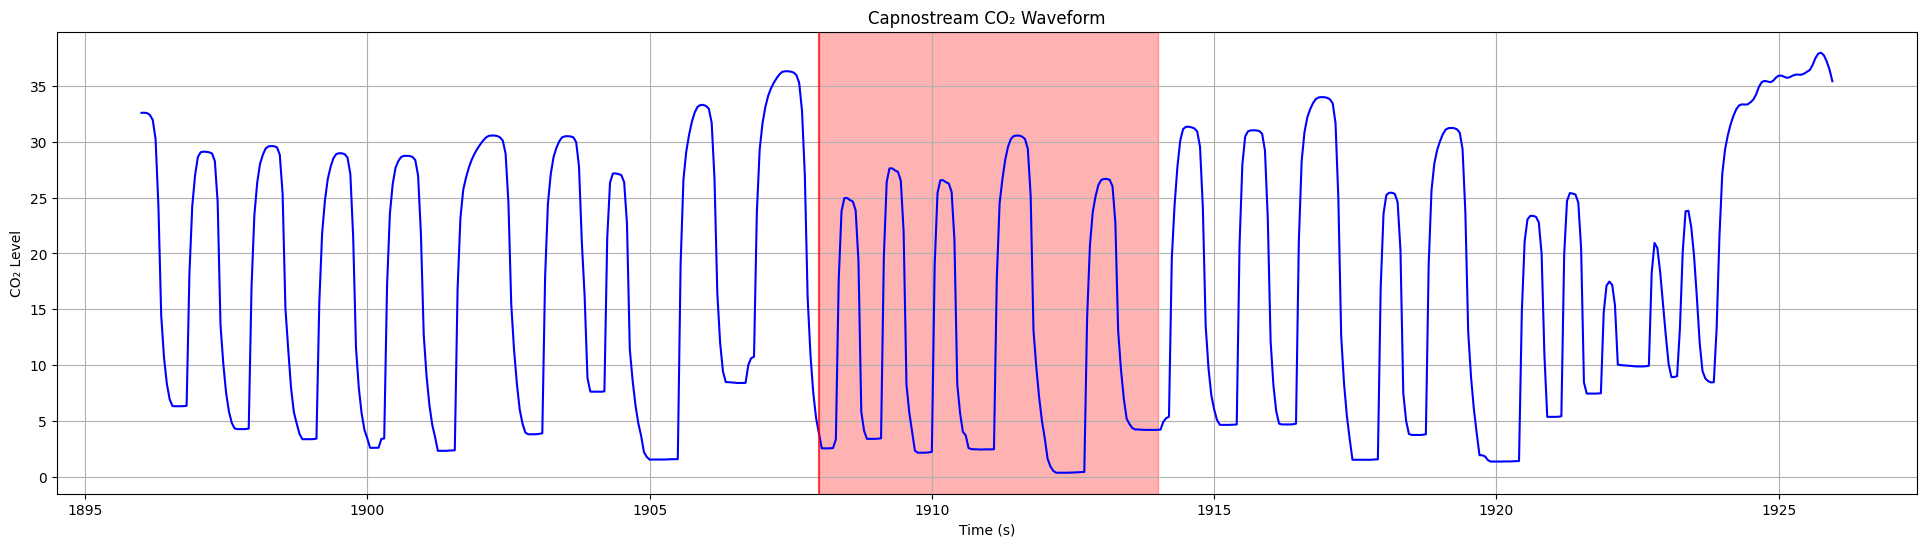

Anomaly at window 322, samples 1932 to 1938, viewing samples (np.int64(1920), np.int64(1950))


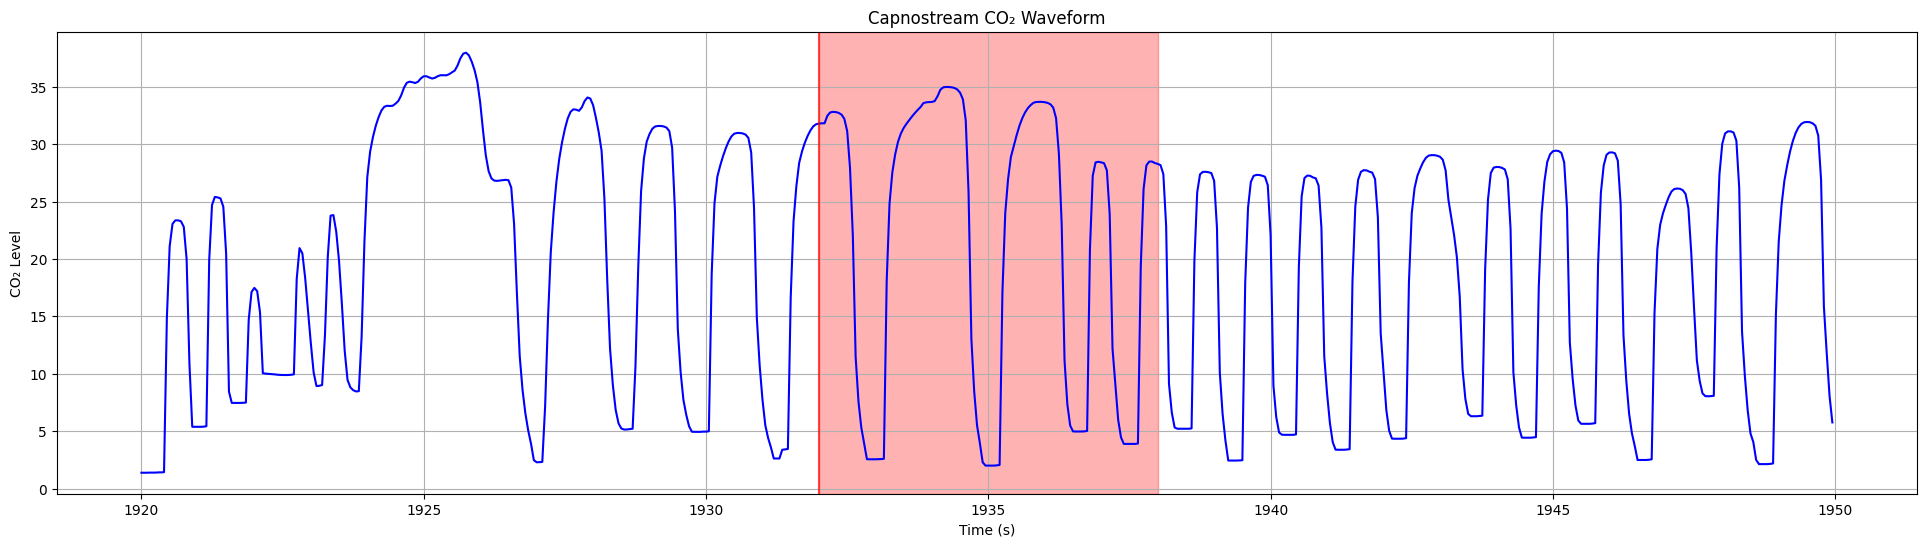

In [6]:
processed_signal = processing.process_signal(signal)

# reconstruct windows and compute errors
recon = dae.predict(processed_signal)
errors = np.mean((processed_signal - recon)**2, axis=1)
# mean_errors = np.mean(errors.reshape(-1, models.constants.capnostream_window_size), axis=1) # todo: use mean errors

# flag anomalies above 95th percentile
threshold = np.percentile(errors, 95)
anomalies = errors > threshold

plotting.plot_capnostream_waveform(signal, anomalies=(models.constants.capnostream_window_size, np.where(anomalies)[0]))

view_margin = models.constants.capnostream_window_size * 2
for anomaly in np.where(anomalies)[0]:
    view_range = (max(0, (anomaly * models.constants.capnostream_window_size) - view_margin), min(len(signal), ((anomaly + 1) * models.constants.capnostream_window_size) + view_margin))
    print(f"Anomaly at window {anomaly}, samples {anomaly * models.constants.capnostream_window_size} to {(anomaly + 1) * models.constants.capnostream_window_size}, viewing samples {view_range}")
    plotting.plot_capnostream_waveform(signal, view_range=view_range, anomalies=(models.constants.capnostream_window_size, np.where(anomalies)[0]))


# todo: use overlapping windows for better resolution and precision
# todo: more labels and validation of labeled data
# todo: try convolutional autoencoder